# **Hamzah Drawsheh 162415**
# **Sentiment Classification using RNN, LSTM, BiLSTM, and Multi-layer LSTM**

In [ ]:
!pip install datasets

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import pandas as pd
#import os
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
#from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, TensorDataset
from datasets import load_dataset
import matplotlib.pyplot as plt


In [24]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [25]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load IMDb Dataset
dataset = load_dataset("imdb")


In [26]:
# Text preprocessing
STOPWORDS = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in STOPWORDS]
    return tokens

dataset['train'] = dataset['train'].map(lambda x: {"text": preprocess_text(x['text'])})
dataset['test'] = dataset['test'].map(lambda x: {"text": preprocess_text(x['text'])})

# Build vocab
word_to_index = {}
index = 1
for data in dataset['train']['text']:
    for word in data:
        if word not in word_to_index:
            word_to_index[word] = index
            index += 1

def encode_text(text):
    return [word_to_index.get(word, 0) for word in text]

dataset['train'] = dataset['train'].map(lambda x: {'text': encode_text(x['text']), 'label': x['label']})
dataset['test'] = dataset['test'].map(lambda x: {'text': encode_text(x['text']), 'label': x['label']})

MAX_LEN = 100

def pad_sequence(seq, max_len):
    return seq[:max_len] + [0] * (max_len - len(seq))

dataset['train'] = dataset['train'].map(lambda x: {'text': pad_sequence(x['text'], MAX_LEN), 'label': x['label']})
dataset['test'] = dataset['test'].map(lambda x: {'text': pad_sequence(x['text'], MAX_LEN), 'label': x['label']})

X_train = torch.tensor(dataset['train']['text'], dtype=torch.long)
y_train = torch.tensor(dataset['train']['label'], dtype=torch.long)
X_test = torch.tensor(dataset['test']['text'], dtype=torch.long)
y_test = torch.tensor(dataset['test']['label'], dtype=torch.long)

BATCH_SIZE = 32
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE)


# **Base RNN Model**

In [27]:
# Base RNN model
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, text):
        embedded = self.embedding(text)
        output, hidden = self.rnn(embedded)
        return self.fc(hidden.squeeze(0))


# **LSTM Model**

In [28]:
# LSTM
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, text):
        embedded = self.embedding(text)
        output, (hidden, cell) = self.lstm(embedded)
        return self.fc(hidden[-1])

# **Bi-LSTM Model**

In [29]:
# BiLSTM
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, text):
        embedded = self.embedding(text)
        output, (hidden, cell) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        return self.fc(hidden)

# **Multi-layer LSTM Model**

In [30]:
# Multi-layer LSTM
class MultiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, text):
        embedded = self.embedding(text)
        output, (hidden, cell) = self.lstm(embedded)
        return self.fc(hidden[-1])

In [31]:
#Training and Evaluation
VOCAB_SIZE = len(word_to_index) + 1
EMBEDDING_DIM = 100
HIDDEN_DIM = 128
OUTPUT_DIM = 2
EPOCHS = 5
def train_and_evaluate(model_class, name):
    model = model_class(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(EPOCHS):
        model.train()
        for texts, labels in train_loader:
            texts, labels = texts.to(device), labels.to(device)
            optimizer.zero_grad()
            predictions = model(texts)
            loss = criterion(predictions, labels)
            loss.backward()
            optimizer.step()

    def evaluate(model, loader):
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for texts, labels in loader:
                texts, labels = texts.to(device), labels.to(device)
                predictions = model(texts)
                predicted = predictions.argmax(1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)
        return correct / total

    train_acc = evaluate(model, train_loader)
    test_acc = evaluate(model, test_loader)
    print(f"{name} - Train Acc: {train_acc:.2f}, Test Acc: {test_acc:.2f}")
    return train_acc, test_acc, model

results = {}
trained_models = {}

for cls, name in zip([RNNClassifier, LSTMClassifier, BiLSTMClassifier, MultiLSTMClassifier],
                     ["RNN", "LSTM", "BiLSTM", "MultiLSTM"]):
    train_acc, test_acc, model = train_and_evaluate(cls, name)
    results[name] = (train_acc, test_acc)
    trained_models[name] = model  # Save the trained model

RNN - Train Acc: 0.53, Test Acc: 0.52
LSTM - Train Acc: 0.95, Test Acc: 0.81
BiLSTM - Train Acc: 0.98, Test Acc: 0.80
MultiLSTM - Train Acc: 0.66, Test Acc: 0.63


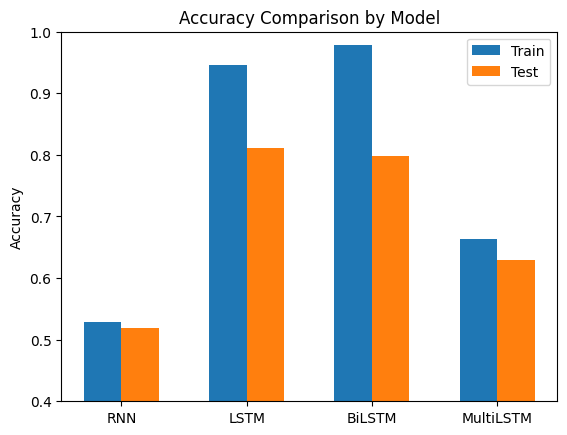

In [32]:
# Bar Chart
labels = list(results.keys())
train_accuracies = [results[m][0] for m in labels]
test_accuracies = [results[m][1] for m in labels]

x = np.arange(len(labels))
width = 0.30
fig, ax = plt.subplots()
ax.bar(x - width/2, train_accuracies, width, label='Train')
ax.bar(x + width/2, test_accuracies, width, label='Test')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy Comparison by Model')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.ylim(0.4, 1.0)
plt.show()


In [34]:
# Function to predict sentiment on new sentences
def predict_sentiment(model, sentence, max_len):
    model.eval()
    sequence = encode_text(preprocess_text(sentence))
    padded_sequence = pad_sequence(sequence, max_len)
    tensor = torch.LongTensor(padded_sequence).unsqueeze(0).to(device)
    prediction = model(tensor)
    return prediction.argmax(1).item()


# Example usage
sentence = "Great film!"
for name in trained_models:
    prediction = predict_sentiment(trained_models[name], sentence, MAX_LEN)
    print(f"{name}: {'+' if prediction==1 else '-'}")

sentence = "Worst movie I've seen."
for name in trained_models:
    prediction = predict_sentiment(trained_models[name], sentence, MAX_LEN)
    print(f"{name}: {'+' if prediction==1 else '-'}")

RNN: +
LSTM: +
BiLSTM: +
MultiLSTM: +
RNN: +
LSTM: -
BiLSTM: -
MultiLSTM: -


# **RNN:**
**Why so low?**

RNNs struggle with long sequences due to the vanishing gradient problem.

They can’t remember long-term dependencies well.

**When to use:** Almost never in real-world NLP anymore. Too limited.

# **LSTM:**
**Why better?**

LSTM has a memory cell that learns long-term dependencies more effectively.

It solves the vanishing gradient issue using gates (input, forget, output).

**When to use:** Great default for most NLP tasks like sentiment analysis

# **Bi-LSTM:**
**Why even better?**

Reads sequences in both forward and backward directions.

This gives the model context from the future and past words.

**When to use:**

Excellent for tasks where context on both sides matters

# **Multi-layer LSTM:**
**Why good?**

Stacking multiple LSTM layers allows deeper feature extraction.

However, too many layers can overfit or become harder to train.

**When to use:**

When you have large datasets and want to learn complex patterns.